PyTorch version: 2.5.1+cu124
Data shape : torch.Size([1000])
Value range: [-1.000, 1.000]
Total pts  : 1000


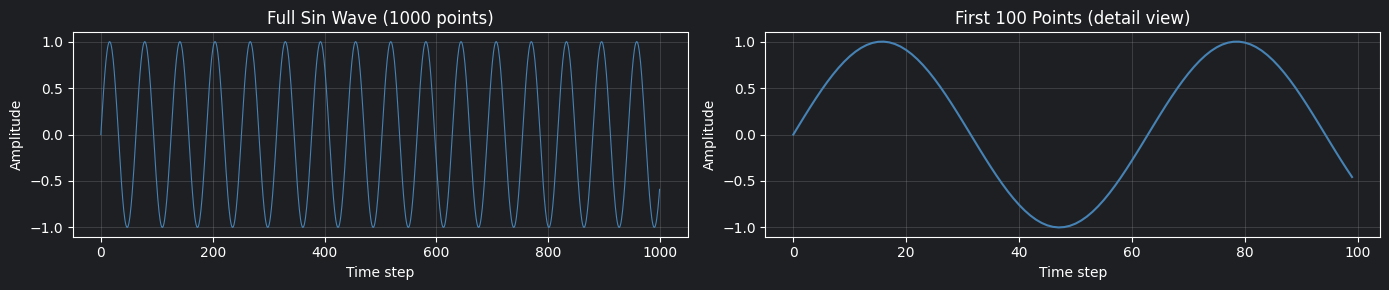

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
plt.rcParams['figure.dpi'] = 100
print(f"PyTorch version: {torch.__version__}")

data = torch.sin(torch.arange(0, 100, 0.1))
print(f"Data shape : {data.shape}")
print(f"Value range: [{data.min():.3f}, {data.max():.3f}]")
print(f"Total pts  : {len(data)}")
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].plot(data.numpy(), linewidth=0.8, color='steelblue')
axes[0].set_title('Full Sin Wave (1000 points)')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(data[:100].numpy(), linewidth=1.5, color='steelblue')
axes[1].set_title('First 100 Points (detail view)')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:

slide_window = 10
X, y = [], []
for i in range(len(data) - slide_window):
    X.append(data[i : i + slide_window])
    y.append(data[i + slide_window])
X = torch.stack(X).unsqueeze(-1)
y = torch.stack(y).unsqueeze(-1)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X shape         : {X.shape} ")
print(f"y shape         : {y.shape} ")

X shape         : torch.Size([990, 10, 1]) 
y shape         : torch.Size([990, 1]) 


In [3]:
import torch.nn as nn
class RNNScratch(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size

        # recurrent weight
        self.W_xh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

        # output projection
        self.W_hy = nn.Parameter(torch.randn(hidden_size, output_size) * 0.1)
        self.b_y = nn.Parameter(torch.zeros(output_size))

    def forward(self, x):
        batch_size = x.size(0)
        h = torch.zeros(batch_size, self.hidden_size)

        for t in range(x.size(1)):
            x_t = x[:, t, :]
            h = torch.tanh(x_t @ self.W_xh + h @ self.W_hh + self.b_h)
        return h @ self.W_hy + self.b_y

scratch_rnn = RNNScratch(input_size=1, hidden_size=64, output_size=1)
total_params = sum(p.numel() for p in scratch_rnn.parameters())
print("RNN Scratch parameters:")
for name, p in scratch_rnn.named_parameters():
    print(f"  {name:8s}: {tuple(p.shape)}  ({p.numel()} values)")
print(f"Total: {total_params} parameters")

RNN Scratch parameters:
  W_xh    : (1, 64)  (64 values)
  W_hh    : (64, 64)  (4096 values)
  b_h     : (64,)  (64 values)
  W_hy    : (64, 1)  (64 values)
  b_y     : (1,)  (1 values)
Total: 4289 parameters


In [5]:
def train_model(model, X_train, y_train, epochs=500, lr=0.01, label='Model'):
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train)
        loss = criterion(pred, y_train)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())


        if (epoch + 1) % 50 == 0:
            print(f"[{label}] Epoch {epoch+1:4d}/{epochs} | Loss: {loss.item():.6f}")

    final = losses[-1]
    status = "pass" if final < 0.01 else "fail"
    print(f"\n[{label}] Final train loss: {final:.6f}  →  Loss < 0.01 : {status}")
    return losses


In [6]:
print("=" * 55)
print("Training RNN Scratch")
print("=" * 55)
losses_scratch = train_model(scratch_rnn, X_train, y_train,
                             epochs=500, lr=0.005, label='Scratch')

Training RNN Scratch
[Scratch] Epoch   50/500 | Loss: 0.000676
[Scratch] Epoch  100/500 | Loss: 0.000084
[Scratch] Epoch  150/500 | Loss: 0.000016
[Scratch] Epoch  200/500 | Loss: 0.000004
[Scratch] Epoch  250/500 | Loss: 0.000002
[Scratch] Epoch  300/500 | Loss: 0.000001
[Scratch] Epoch  350/500 | Loss: 0.000001
[Scratch] Epoch  400/500 | Loss: 0.000001
[Scratch] Epoch  450/500 | Loss: 0.000001
[Scratch] Epoch  500/500 | Loss: 0.000001

[Scratch] Final train loss: 0.000001  →  Loss < 0.01 : pass


Scratch RNN — Test Loss: 0.000001


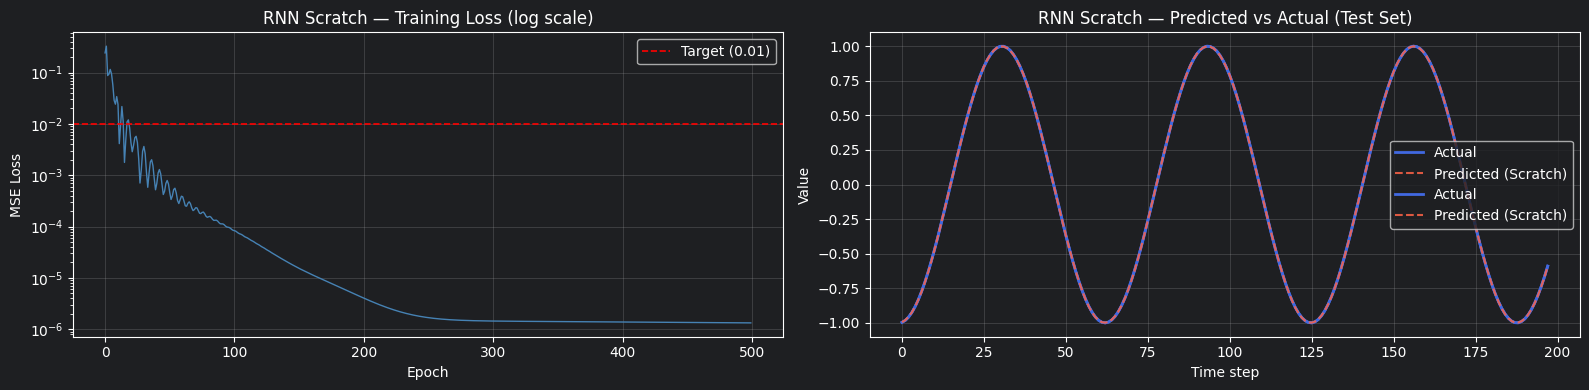

In [12]:
with torch.no_grad():
    pred_scratch = scratch_rnn(X_test)
test_loss_scratch = nn.MSELoss()(pred_scratch, y_test).item()
print(f"Scratch RNN — Test Loss: {test_loss_scratch:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Loss curve
axes[0].plot(losses_scratch, color='steelblue', linewidth=1)
axes[0].axhline(y=0.01, color='red', linestyle='--', linewidth=1.2, label='Target (0.01)')
axes[0].set_yscale('log')
axes[0].set_title('RNN Scratch — Training Loss (log scale)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# Predicted vs Actual
actual = y_test.squeeze().numpy()
pred_s = pred_scratch.squeeze().numpy()
axes[1].plot(actual, label='Actual', color='royalblue', linewidth=2)
axes[1].plot(pred_s,  label='Predicted (Scratch)', color='tomato',
             linestyle='--', linewidth=1.5, alpha=0.85)
axes[1].set_title('RNN Scratch — Predicted vs Actual (Test Set)')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[1].plot(actual, label='Actual', color='royalblue', linewidth=2)
axes[1].plot(pred_s,  label='Predicted (Scratch)', color='tomato',
             linestyle='--', linewidth=1.5, alpha=0.85)
axes[1].set_title('RNN Scratch — Predicted vs Actual (Test Set)')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)              # out: (batch, seq_len, hidden)
        return self.fc(out[:, -1, :])     # lấy hidden state cuối: (batch, 1)


nn_rnn = RNNModel(input_size=1, hidden_size=64, output_size=1)
total_params_nn = sum(p.numel() for p in nn_rnn.parameters())
print(f"nn.RNN model — Total parameters: {total_params_nn}")

print("\n" + "=" * 55)
print("Training nn.RNN")
print("=" * 55)
losses_nn = train_model(nn_rnn, X_train, y_train,
                        epochs=500, lr=0.005, label='nn.RNN')

nn.RNN model — Total parameters: 4353

Training nn.RNN
[nn.RNN] Epoch   50/500 | Loss: 0.000438
[nn.RNN] Epoch  100/500 | Loss: 0.000122
[nn.RNN] Epoch  150/500 | Loss: 0.000059
[nn.RNN] Epoch  200/500 | Loss: 0.000034
[nn.RNN] Epoch  250/500 | Loss: 0.000021
[nn.RNN] Epoch  300/500 | Loss: 0.000012
[nn.RNN] Epoch  350/500 | Loss: 0.000007
[nn.RNN] Epoch  400/500 | Loss: 0.000004
[nn.RNN] Epoch  450/500 | Loss: 0.000002
[nn.RNN] Epoch  500/500 | Loss: 0.000001

[nn.RNN] Final train loss: 0.000001  →  Loss < 0.01 : pass


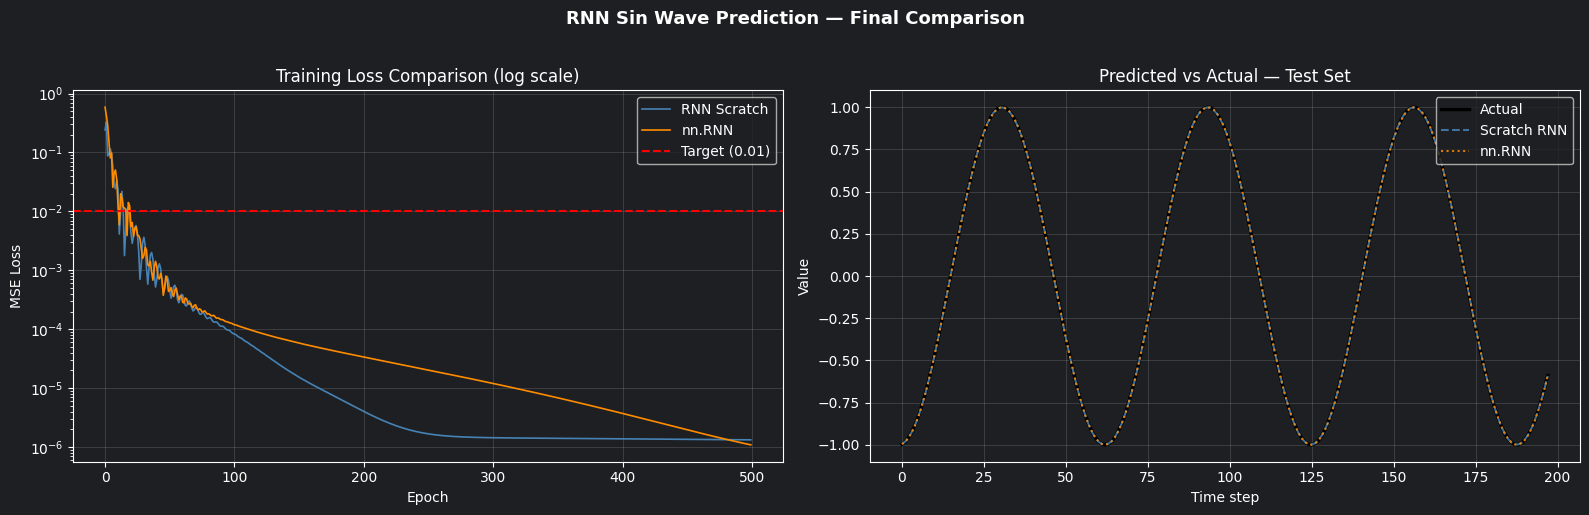

Test Loss — Scratch : 0.000001
Test Loss — nn.RNN  : 0.000001


In [14]:
# Evaluate nn.RNN on test set
nn_rnn.eval()
with torch.no_grad():
    pred_nn = nn_rnn(X_test)

test_loss_nn = nn.MSELoss()(pred_nn, y_test).item()

actual  = y_test.squeeze().numpy()
pred_s  = pred_scratch.squeeze().numpy()
pred_n  = pred_nn.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Loss comparison ---
axes[0].plot(losses_scratch, label='RNN Scratch', color='steelblue', linewidth=1.2)
axes[0].plot(losses_nn,      label='nn.RNN',      color='darkorange', linewidth=1.2)
axes[0].axhline(y=0.01, color='red', linestyle='--', linewidth=1.5, label='Target (0.01)')
axes[0].set_yscale('log')
axes[0].set_title('Training Loss Comparison (log scale)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Prediction comparison ---
axes[1].plot(actual, label='Actual',      color='black',      linewidth=2.5)
axes[1].plot(pred_s, label='Scratch RNN', color='steelblue',  linestyle='--', linewidth=1.5, alpha=0.85)
axes[1].plot(pred_n, label='nn.RNN',      color='darkorange', linestyle=':',  linewidth=1.5, alpha=0.85)
axes[1].set_title('Predicted vs Actual — Test Set')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('RNN Sin Wave Prediction — Final Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Test Loss — Scratch : {test_loss_scratch:.6f}")
print(f"Test Loss — nn.RNN  : {test_loss_nn:.6f}")

In [15]:
def check(cond): return '✓ PASSED' if cond else '✗ FAILED'

print("=" * 55)
print("VERIFICATION REPORT")
print("=" * 55)
print(f"Data shape         : X={X.shape}, y={y.shape}")
print(f"  → X=(990,10,1)   : {check(X.shape == torch.Size([990, 10, 1]))}")
print()
print(f"Scratch Train Loss : {losses_scratch[-1]:.6f}")
print(f"  → Loss < 0.01    : {check(losses_scratch[-1] < 0.01)}")
print()
print(f"nn.RNN  Train Loss : {losses_nn[-1]:.6f}")
print(f"  → Loss < 0.01    : {check(losses_nn[-1] < 0.01)}")
print()
ratio = abs(losses_scratch[-1] - losses_nn[-1]) / max(losses_scratch[-1], losses_nn[-1])
print(f"Loss difference    : {ratio*100:.1f}%")
print(f"  → Equivalent     : {check(ratio < 0.5)} (within 50%)")
print()
print(f"Scratch Test Loss  : {test_loss_scratch:.6f}")
print(f"nn.RNN  Test Loss  : {test_loss_nn:.6f}")
print("=" * 55)

VERIFICATION REPORT
Data shape         : X=torch.Size([990, 10, 1]), y=torch.Size([990, 1])
  → X=(990,10,1)   : ✓ PASSED

Scratch Train Loss : 0.000001
  → Loss < 0.01    : ✓ PASSED

nn.RNN  Train Loss : 0.000001
  → Loss < 0.01    : ✓ PASSED

Loss difference    : 17.7%
  → Equivalent     : ✓ PASSED (within 50%)

Scratch Test Loss  : 0.000001
nn.RNN  Test Loss  : 0.000001
